*RAW-window-normalize-peaks
raw-*WINDOW-normalize-peaks


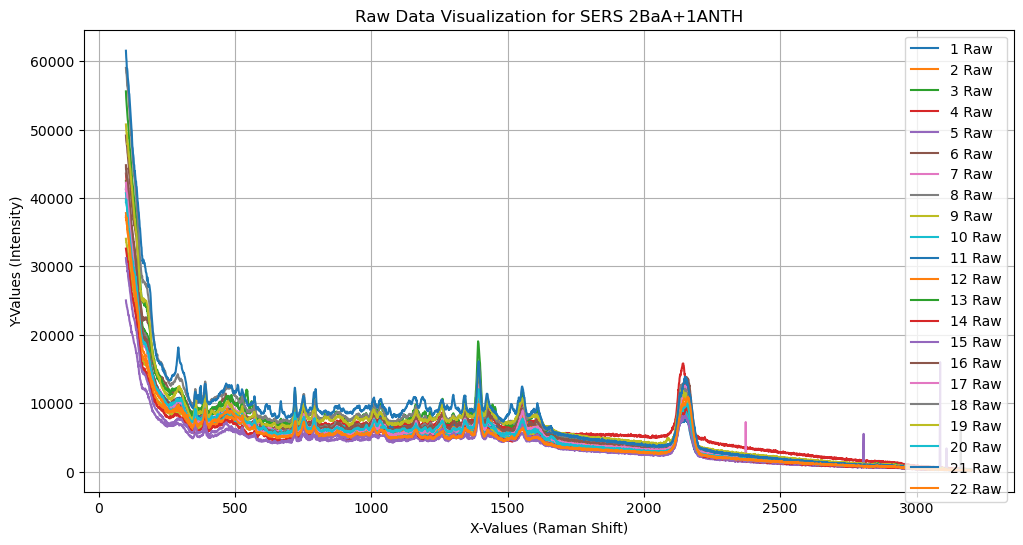

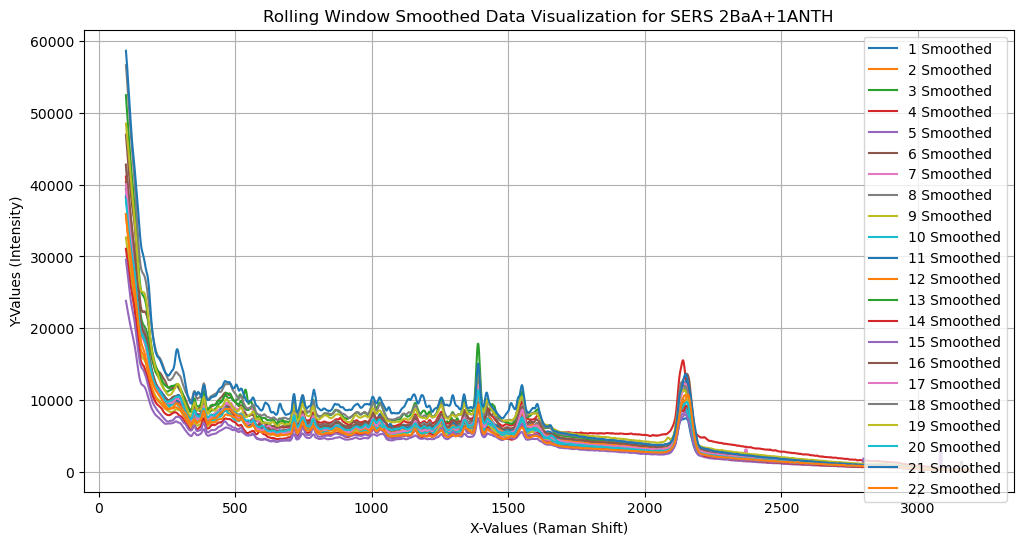

In [14]:
import os
import matplotlib.pyplot as plt
from preprocessor import Preprocessor

# Set your working directory and initialize the Preprocessor
os.chdir("C:\\Users\\23675\\OneDrive - UW-Madison\\Desktop\\research final")
pre_processor = Preprocessor(file_path='raw_dataset\SERS 2BaA+1ANTH.xlsx',
                             m=10, threshold=20, mat_iteration=100, windows_size=10, prominence=0.02)

# Load raw data using the pre_processor instance
x_values, y_values_dict = pre_processor.load_raw_data(pre_processor.file_path)

# Apply rolling window smoothing
y_smoothed_dict = pre_processor.apply_rolling_window(y_values_dict)

# First plot: Raw Data
plt.figure(figsize=(12, 6))
for sample_name, y_values in y_values_dict.items():
    plt.plot(x_values, y_values, label=f"{sample_name} Raw")
plt.title("Raw Data Visualization for SERS 2BaA+1ANTH")
plt.xlabel("X-Values (Raman Shift)")
plt.ylabel("Y-Values (Intensity)")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Second plot: Rolling Window Smoothed Data
plt.figure(figsize=(12, 6))
for sample_name, y_smoothed in y_smoothed_dict.items():
    plt.plot(x_values, y_smoothed, label=f"{sample_name} Smoothed")
plt.title("Rolling Window Smoothed Data Visualization for SERS 2BaA+1ANTH")
plt.xlabel("X-Values (Raman Shift)")
plt.ylabel("Y-Values (Intensity)")
plt.grid(True)
plt.show()


*RAW-window-normalize-peaks


<IPython.core.display.Javascript object>

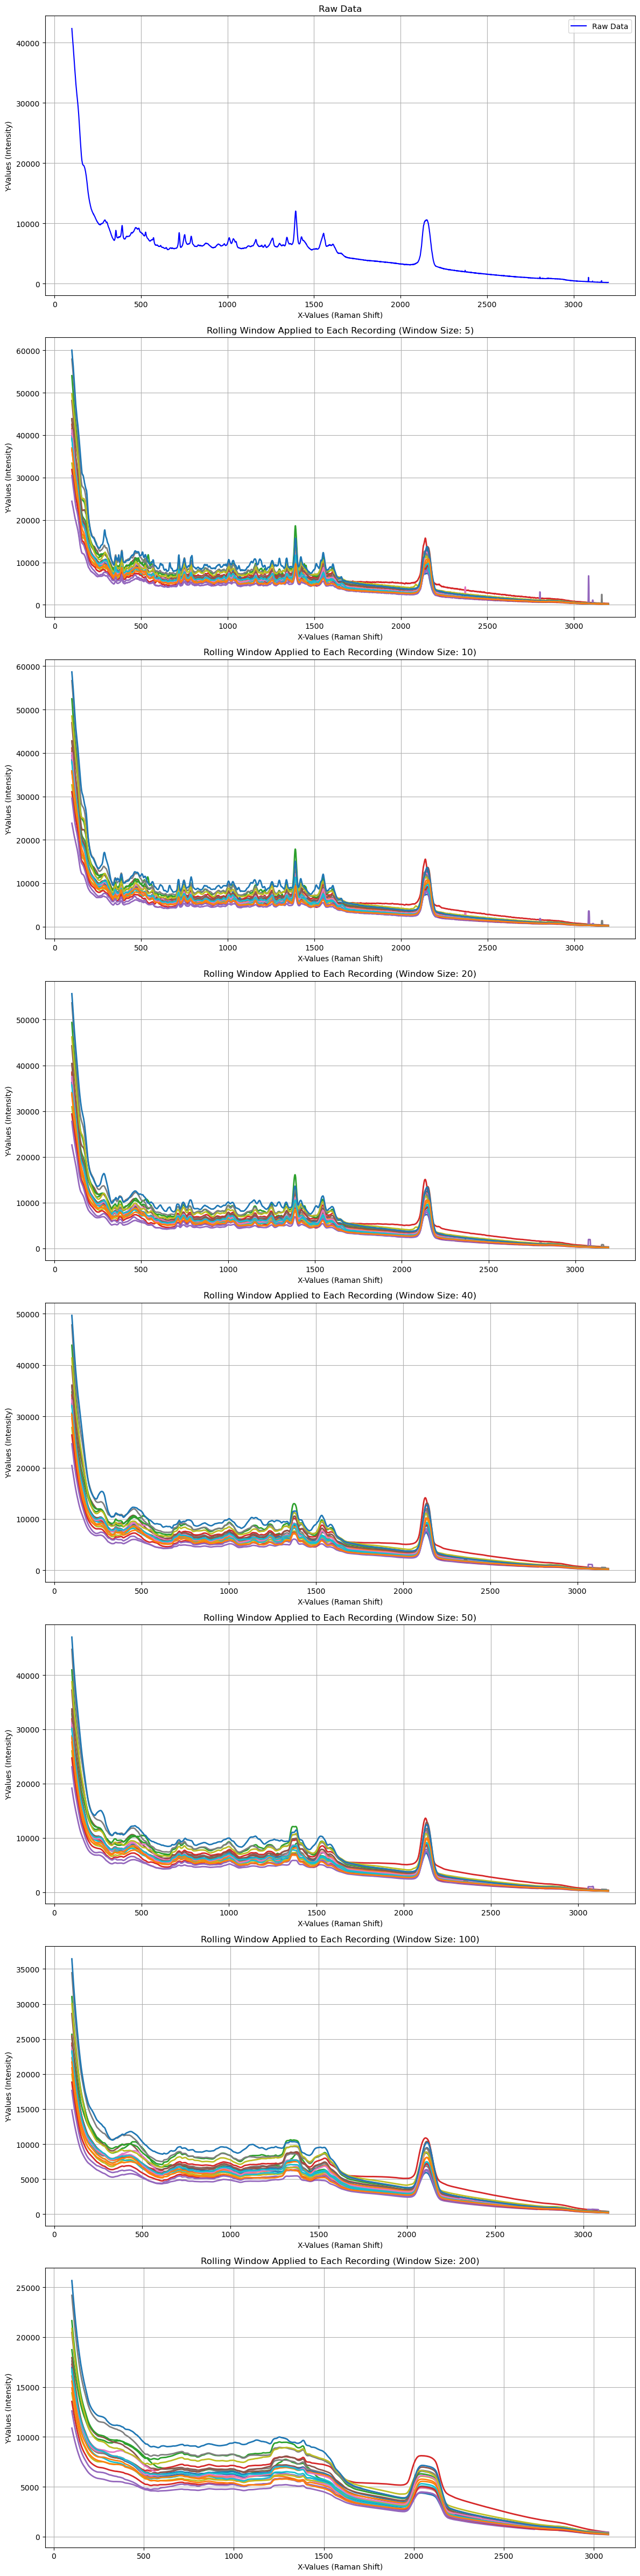

In [16]:
import os
from preprocessor import Preprocessor
import matplotlib.pyplot as plt
# Set your working directory and initialize the Preprocessor
os.chdir("C:\\Users\\23675\\OneDrive - UW-Madison\\Desktop\\research final")
pre_processor = Preprocessor(file_path='raw_dataset\SERS 2BaA+1ANTH.xlsx',
                             m=10, threshold=20, mat_iteration=100, windows_size=10, prominence=0.02)

# Load raw data using the pre_processor instance
x_values, y_values_dict = pre_processor.load_raw_data(pre_processor.file_path)

# Calculate the mean of the raw data
y_mean_raw = pd.DataFrame(y_values_dict).mean(axis=1)

# Define the window sizes
window_sizes = [5, 10, 20, 40, 50, 100, 200]

# Plotting
fig, axes = plt.subplots(len(window_sizes) + 1, 1, figsize=(12, 6 * (len(window_sizes) + 1)))  # rows = len(window_sizes) + 1, columns = 1

# Raw Data Plot
axes[0].plot(x_values, y_mean_raw, label='Raw Data', color='blue')
axes[0].set_title('Raw Data')
axes[0].set_xlabel('X-Values (Raman Shift)')
axes[0].set_ylabel('Y-Values (Intensity)')
axes[0].legend()
axes[0].grid(True)

# Iterate over the window sizes and generate plots
for i, window_size in enumerate(window_sizes):
    # Apply a rolling window to each recording
    for sample_name, y_values in y_values_dict.items():
        y_rolling = y_values.rolling(window=window_size).mean()

        # Rolling Window Plot
        axes[i + 1].plot(x_values, y_rolling, label=f'{sample_name} (Window Size: {window_size})', linewidth=2)
    axes[i + 1].set_title(f'Rolling Window Applied to Each Recording (Window Size: {window_size})')
    axes[i + 1].set_xlabel('X-Values (Raman Shift)')
    axes[i + 1].set_ylabel('Y-Values (Intensity)')
    axes[i + 1].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# save the image to fig folder
fig.savefig('fig\\Rolling Window Applied to Each Recording.png', dpi=300)


# Data visualization

*RAW-window-normalize-peaks
raw-window-*NORMALIZE-peaks


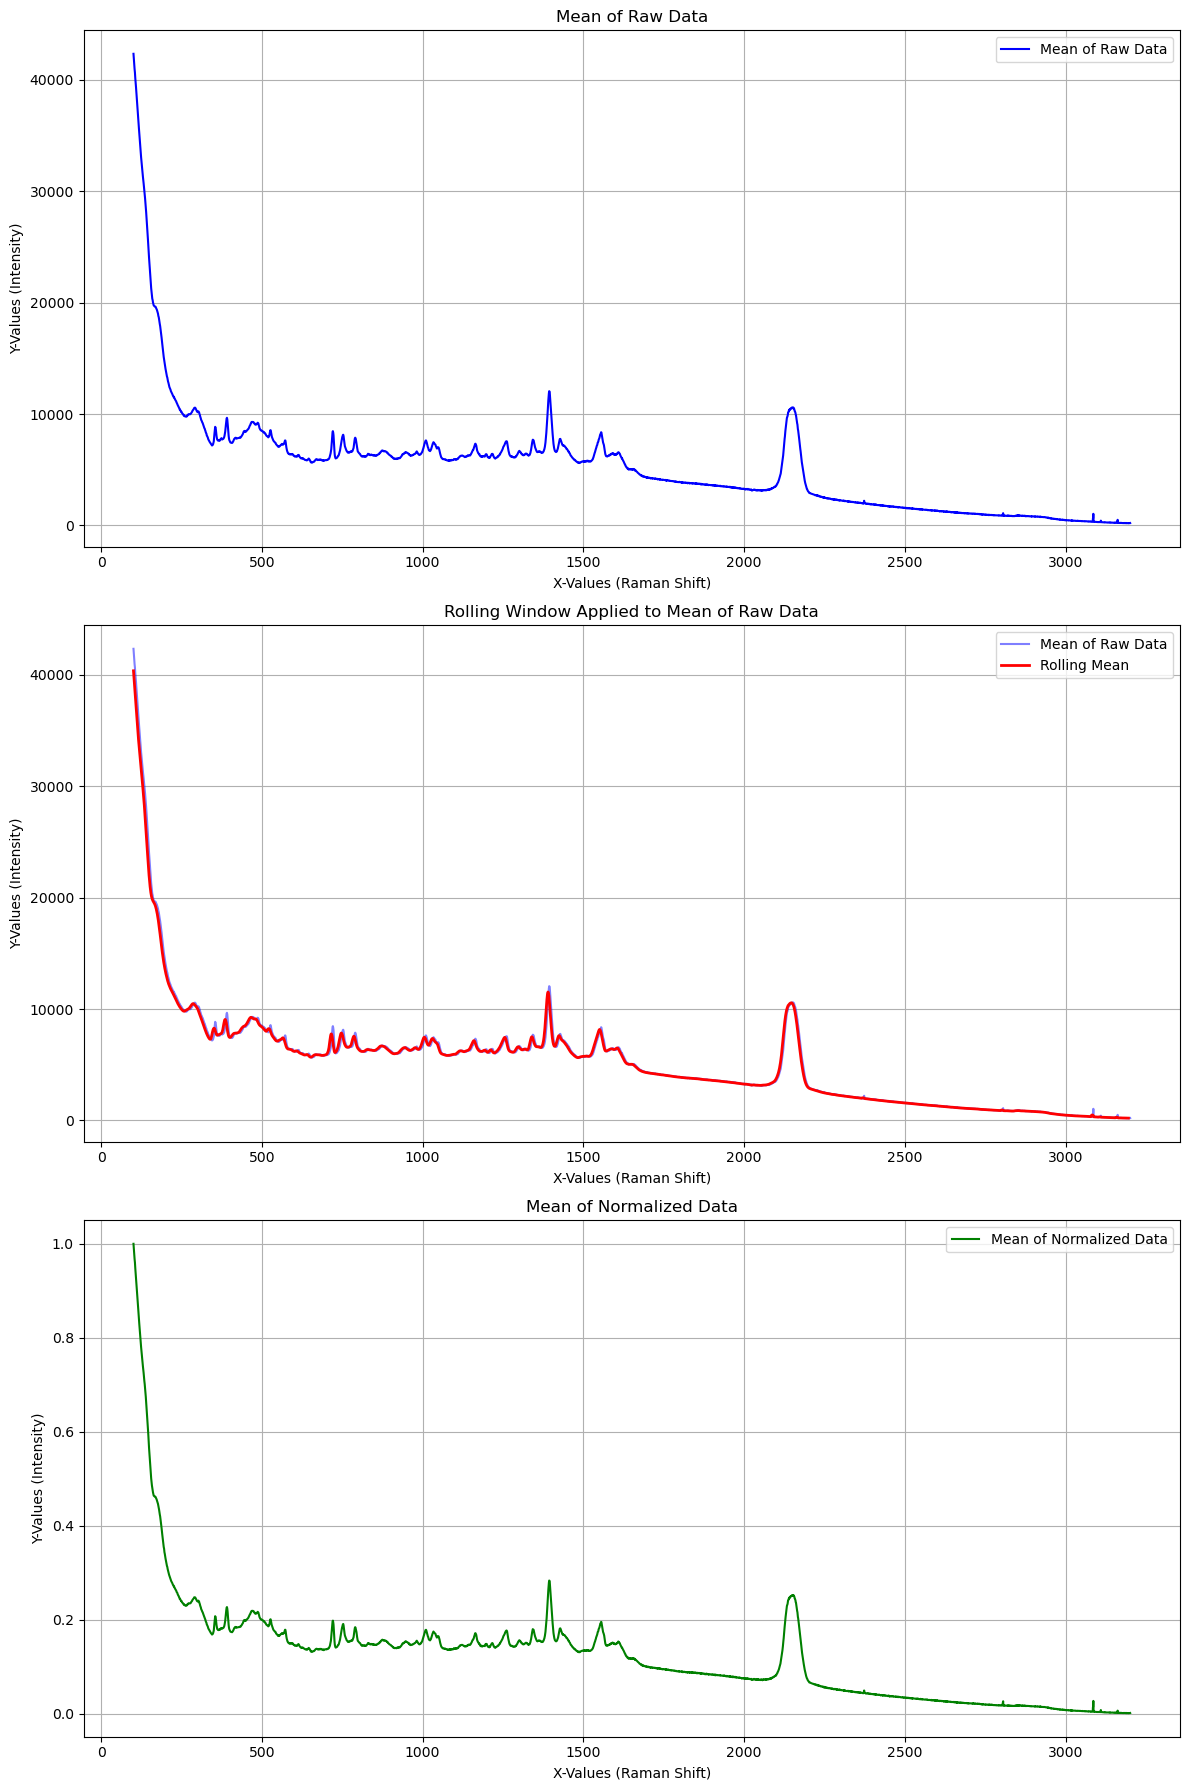

In [49]:
# Assuming pre_processor is already created and initialized

# Load raw data using the pre_processor instance
x_values, y_values_dict = pre_processor.load_raw_data(pre_processor.file_path)

# Calculate the mean of the raw data
y_mean_raw = pd.DataFrame(y_values_dict).mean(axis=1)

# Apply a rolling window to the mean of the raw data
rolling_window_size = 10  # Adjust as needed
y_mean_rolling = y_mean_raw.rolling(window=rolling_window_size).mean()

# Normalize the raw data using the pre_processor instance
y_normalized_dict = pre_processor.normalize_data(y_values_dict)
y_normalized_mean = pd.DataFrame(y_normalized_dict).mean(axis=1)

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 18))  # 3 rows, 1 column

# Raw Data Plot
axes[0].plot(x_values, y_mean_raw, label='Mean of Raw Data', color='blue')
axes[0].set_title('Mean of Raw Data')
axes[0].set_xlabel('X-Values (Raman Shift)')
axes[0].set_ylabel('Y-Values (Intensity)')
axes[0].legend()
axes[0].grid(True)

# Rolling Window Plot
axes[1].plot(x_values, y_mean_raw, label='Mean of Raw Data', color='blue', alpha=0.5)
axes[1].plot(x_values, y_mean_rolling, label='Rolling Mean', color='red', linewidth=2)
axes[1].set_title('Rolling Window Applied to Mean of Raw Data')
axes[1].set_xlabel('X-Values (Raman Shift)')
axes[1].set_ylabel('Y-Values (Intensity)')
axes[1].legend()
axes[1].grid(True)

# Normalized Data Plot
axes[2].plot(x_values, y_normalized_mean, label='Mean of Normalized Data', color='green')
axes[2].set_title('Mean of Normalized Data')
axes[2].set_xlabel('X-Values (Raman Shift)')
axes[2].set_ylabel('Y-Values (Intensity)')
axes[2].legend()
axes[2].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()
